# Example 8 — MNIST-CP contour point clouds with denoising score matching

Experiment 7 tried to learn full MNIST weighted pixel point clouds.  This notebook switches to the easier **MNIST-CP** representation generated by `mnist/generate_mnist_cp.py`: each digit is represented by uniformly sampled points along the outline contour.

The score model is still the finite-dimensional frozen-mass score model used in Experiment 7.  The important simplification is that all atoms now have the same mass and the geometry is a contour set rather than a sparse weighted image measure.

The default run below uses a finite-horizon empirical score sampler: it starts from real MNIST-CP contours noised at `tau = HORIZON`, then integrates the learned reverse dynamics.  This is the most direct check that the score-matching objective has learned the contour distribution.  A uniform-prior ablation is included at the end, but it is intentionally not the default because matching an explicit prior at large `T` is a separate modeling problem.

## Score-matching setup

For a clean contour cloud

$$
X = (X_1, \ldots, X_K), \qquad s_i = 1/K,
$$

the free finite-particle heat kernel perturbs positions by

$$
Y_i = X_i + \sqrt{\frac{2\tau}{s_i}} Z_i.
$$

The Euclidean denoising score target for the weighted gradient is

$$
D^{(K)}_{y_i}\log p_{\tau,s}(y \mid x)
= -\frac{y_i - x_i}{2\tau},
\qquad D_i^{(K)} = \frac{1}{s_i}\nabla_{y_i}.
$$

Because MNIST-CP contours are normalized to a box rather than a torus, this notebook defaults to `SCORE_PROJECTION='none'` and `SCORE_TARGET='euclidean'`.  Points are displayed in the unit-square chart, after mapping the saved `[-1, 1]^2` MNIST-CP coordinates to `[0, 1]^2`.

In [1]:
from __future__ import annotations

from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mnist.conditioned_diffusion import (
    GeneratedPointCloudSet,
    TerminalSetClassifier,
    evaluate_terminal_set_classifier,
    predict_terminal_logits,
    confusion_matrix_from_predictions,
    project_positions,
)
from mnist.experiment6_fixes import train_terminal_set_classifier_noisy
from mnist.mnist_cp import (
    evaluate_mnist_cp_generation_metrics,
    load_mnist_cp_splits,
    unit_square_to_mnist_cp_points,
)
from mnist.score_matching import (
    ConditionalScoreImageFieldNetwork,
    ConditionalScoreSetNetwork,
    ConditionalScoreSetTransformer,
    diagnose_score_prior_horizons,
    evaluate_score_model_by_tau_bins,
    generate_balanced_score_matching_dataset,
    perturb_weighted_point_cloud_positions,
    recommend_score_prior_horizon,
    train_score_model,
)
from mnist.weighted_point_cloud import rasterize_weighted_point_clouds

SEED = 1234
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("repo root:", REPO_ROOT)
print("device:", DEVICE)


repo root: C:\Users\mao17\Workspace\condition_df
device: cuda


In [2]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def softmax_np(logits: np.ndarray) -> np.ndarray:
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.maximum(exp.sum(axis=1, keepdims=True), 1e-12)


def plot_confusion_matrix(matrix: np.ndarray, *, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    im = ax.imshow(matrix, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()


set_all_seeds(SEED)

In [18]:
FAST_DEMO = False

# Use POINTS_PER_CLOUD=None for all 800 saved MNIST-CP contour points.
# The demo uses fewer points so the notebook is runnable on modest hardware.
#
# Important scaling note:
# if s_i = 1 / K then the forward perturbation has per-particle standard deviation
#     sigma(tau) = sqrt(2 tau / s_i) = sqrt(2 K tau).
# For K = 800, HORIZON = 5e-5 corresponds to roughly 0.283 in unit-square coordinates,
# i.e. almost 8 MNIST pixels of endpoint noise.  That is unnecessarily hard for
# contour denoising, so we use a much smaller horizon here.
if FAST_DEMO:
    TRAIN_PER_CLASS = 256
    VAL_PER_CLASS = 64
    TEST_PER_CLASS = 64
    POINTS_PER_CLOUD = 256

    AUX_CLASSIFIER_EPOCHS = 4
    AUX_CLASSIFIER_BATCH_SIZE = 64
    AUX_CLASSIFIER_LR = 2e-3

    SCORE_EPOCHS = 12
    SCORE_BATCH_SIZE = 24
    SCORE_LR = 1e-3
    SCORE_ARCHITECTURE = "image_field"
    SCORE_POINT_FEATURE_DIM = 96
    SCORE_HIDDEN_DIM = 192
    SCORE_CONDITIONING_DIM = 48
    SCORE_TRANSFORMER_LAYERS = 2
    SCORE_TRANSFORMER_HEADS = 4
    SCORE_TRANSFORMER_DROPOUT = 0.05
    SCORE_GRID_SIZE = 48
    SCORE_BASE_CHANNELS = 32
    SCORE_GRID_FEATURE_DIM = 64

    SYNTHETIC_PER_CLASS = 16
    HORIZON = 1.0e-5
    TARGET_STEP_SIZE = HORIZON / 100.0
    CHAMFER_SUBSAMPLE_PER_CLASS = 8

    RUN_T_DIAGNOSTIC = False
    T_DIAGNOSTIC_MAX_SAMPLES = 256
    T_DIAGNOSTIC_CLASSIFIER_EPOCHS = 10
    RUN_UNIFORM_PRIOR_ABLATION = False
else:
    TRAIN_PER_CLASS = 2000
    VAL_PER_CLASS = 250
    TEST_PER_CLASS = 250
    POINTS_PER_CLOUD = None  # all 800 contour points

    AUX_CLASSIFIER_EPOCHS = 12
    AUX_CLASSIFIER_BATCH_SIZE = 128
    AUX_CLASSIFIER_LR = 1e-3

    SCORE_EPOCHS = 100
    SCORE_BATCH_SIZE = 16
    SCORE_LR = 5e-4
    SCORE_ARCHITECTURE = "image_field"
    SCORE_POINT_FEATURE_DIM = 128
    SCORE_HIDDEN_DIM = 256
    SCORE_CONDITIONING_DIM = 64
    SCORE_TRANSFORMER_LAYERS = 3
    SCORE_TRANSFORMER_HEADS = 4
    SCORE_TRANSFORMER_DROPOUT = 0.05
    SCORE_GRID_SIZE = 56
    SCORE_BASE_CHANNELS = 48
    SCORE_GRID_FEATURE_DIM = 96

    SYNTHETIC_PER_CLASS = 128
    HORIZON = 7.0e-6
    TARGET_STEP_SIZE = HORIZON / 100.0
    CHAMFER_SUBSAMPLE_PER_CLASS = 24

    RUN_T_DIAGNOSTIC = True
    T_DIAGNOSTIC_MAX_SAMPLES = 1024
    T_DIAGNOSTIC_CLASSIFIER_EPOCHS = 30
    RUN_UNIFORM_PRIOR_ABLATION = True

REVERSE_STEPS = int(np.ceil(HORIZON / TARGET_STEP_SIZE))
STEP_SIZE = HORIZON / REVERSE_STEPS
TAU_MIN = STEP_SIZE
TAU_MAX = HORIZON

SCORE_PROJECTION = "none"
SCORE_TARGET = "euclidean"
SCORE_TAU_SAMPLING = "log_uniform"
SCORE_OUTPUT_SCALING = "tau_mass"
SCORE_TIME_WEIGHTING = "sigma2"
SAMPLER_SCHEME = "bridge"
SCORE_SCALE = 1.2
DIFFUSION_TEMPERATURE = 0.25

# The primary sampler is intentionally the finite-horizon empirical sampler.
PRIMARY_INITIAL_POSITION_MODE = "forward_noised_bank"
UNIFORM_INITIAL_POSITION_MODE = "uniform"

MNIST_CP_PATH = REPO_ROOT / "mnist_data" / "mnist_cp.npz"

def endpoint_noise_summary(num_points: int, horizon: float) -> tuple[float, float]:
    sigma_unit = float(np.sqrt(2.0 * horizon * num_points))
    sigma_pixels = 28.0 * sigma_unit
    return sigma_unit, sigma_pixels

sigma_unit, sigma_pixels = endpoint_noise_summary(
    POINTS_PER_CLOUD if POINTS_PER_CLOUD is not None else 800,
    HORIZON,
)
print("FAST_DEMO =", FAST_DEMO)
print("MNIST-CP path =", MNIST_CP_PATH)
print("points per contour =", POINTS_PER_CLOUD if POINTS_PER_CLOUD is not None else "all saved points")
print("train/val/test per class =", (TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS))
print("tau range =", (TAU_MIN, TAU_MAX), "reverse steps =", REVERSE_STEPS)
print("score projection/target =", (SCORE_PROJECTION, SCORE_TARGET))
print("sampler scheme =", SAMPLER_SCHEME)
print("score architecture =", SCORE_ARCHITECTURE)
print("score scale / diffusion temperature =", (SCORE_SCALE, DIFFUSION_TEMPERATURE))
print("approx endpoint noise std =", f"{sigma_unit:.4f} in unit-square coords ≈ {sigma_pixels:.2f} MNIST pixels")


FAST_DEMO = False
MNIST-CP path = C:\Users\mao17\Workspace\condition_df\mnist_data\mnist_cp.npz
points per contour = all saved points
train/val/test per class = (2000, 250, 250)
tau range = (7e-08, 7e-06) reverse steps = 100
score projection/target = ('none', 'euclidean')
sampler scheme = bridge
score architecture = image_field
score scale / diffusion temperature = (1.2, 0.25)
approx endpoint noise std = 0.1058 in unit-square coords ≈ 2.96 MNIST pixels


## Load MNIST-CP

`mnist_cp.npz` stores contour coordinates in `[-1, 1]^2`.  The loader maps them to `[0, 1]^2` and gives every contour point mass `1/K`.  The train/validation/reference splits are balanced and disjoint within the saved 60k pool.

In [4]:
splits = load_mnist_cp_splits(
    MNIST_CP_PATH,
    train_per_class=TRAIN_PER_CLASS,
    val_per_class=VAL_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    num_points=POINTS_PER_CLOUD,
    seed=SEED,
    load_images=True,
)
train_pc = splits.train
val_pc = splits.val
test_pc = splits.test

K = train_pc.num_points
print("normalization:", splits.normalization)
print("train:", train_pc.positions.shape, train_pc.masses.shape)
print("val  :", val_pc.positions.shape, val_pc.masses.shape)
print("test :", test_pc.positions.shape, test_pc.masses.shape)
print("class counts train:", np.bincount(train_pc.labels, minlength=10))
print("uniform mass per atom:", train_pc.masses[0, 0], "sum:", train_pc.masses[0].sum())

normalization: bbox_centered_longest_side_to_[-1,1]
train: (20000, 800, 2) (20000, 800)
val  : (2500, 800, 2) (2500, 800)
test : (2500, 800, 2) (2500, 800)
class counts train: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]
uniform mass per atom: 0.00125 sum: 0.9999999


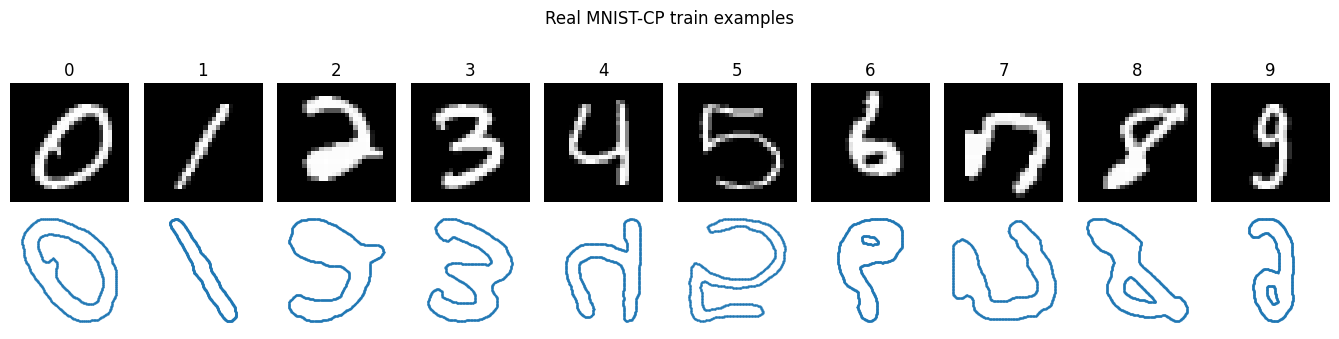

In [5]:
def plot_mnist_cp_gallery(
    positions: np.ndarray,
    labels: np.ndarray,
    *,
    images: np.ndarray | None = None,
    examples_per_label: int = 2,
    title: str | None = None,
    seed: int = 0,
    point_size: float = 1.0,
    alpha: float = 0.8,
) -> None:
    rng = np.random.default_rng(seed)
    rows = []
    for label in range(10):
        idx = np.flatnonzero(labels == label)
        if len(idx) == 0:
            continue
        chosen = rng.choice(idx, size=min(examples_per_label, len(idx)), replace=False)
        rows.extend(chosen.tolist())

    n = len(rows)
    if n == 0:
        print("no examples to plot")
        return

    show_images = images is not None
    height = 3.4 if show_images else 1.9
    fig, axes = plt.subplots(2 if show_images else 1, n, figsize=(1.35 * n, height), squeeze=False)

    for col, idx in enumerate(rows):
        label = int(labels[idx])
        if show_images:
            axes[0, col].imshow(images[idx], cmap="gray", interpolation="nearest")
            axes[0, col].set_title(str(label))
            axes[0, col].axis("off")
            ax = axes[1, col]
        else:
            ax = axes[0, col]
            ax.set_title(str(label))
        pts = positions[idx]
        ax.scatter(pts[:, 0], pts[:, 1], s=point_size, alpha=alpha)
        ax.set_aspect("equal")
        ax.set_xlim(-0.08, 1.08)
        ax.set_ylim(1.08, -0.08)
        ax.axis("off")

    if title is not None:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()


plot_mnist_cp_gallery(
    train_pc.positions,
    train_pc.labels,
    images=train_pc.images,
    examples_per_label=1,
    title="Real MNIST-CP train examples",
    seed=SEED,
    point_size=1.2 if K <= 300 else 0.4,
)

## Optional horizon diagnostic

For a truly independent uniform start, the forward-noised data at `tau = HORIZON` should be close to uniform.  This diagnostic mirrors Experiment 7.  It is not required for the default empirical forward-noised sampler, but it is useful when enabling the uniform-prior ablation.

In [6]:
if RUN_T_DIAGNOSTIC:
    candidate_horizons = HORIZON * np.asarray([0.5, 1.0, 2.0, 4.0, 8.0], dtype=np.float64)
    horizon_rows = diagnose_score_prior_horizons(
        train_pc.masses,
        train_pc.positions,
        train_pc.labels,
        candidate_horizons,
        projection=SCORE_PROJECTION,
        prior_position_mode="uniform",
        max_samples=T_DIAGNOSTIC_MAX_SAMPLES,
        feature_grid_size=8,
        classifier_epochs=T_DIAGNOSTIC_CLASSIFIER_EPOCHS,
        classifier_batch_size=128,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 7),
    )
    horizon_df = pd.DataFrame(horizon_rows)
    recommended = recommend_score_prior_horizon(
        horizon_rows,
        max_prior_accuracy=0.56,
        label_accuracy_slack=0.05,
    )
    print("recommended horizon:", recommended)
    display(horizon_df)
else:
    horizon_df = None

recommended horizon: {'horizon': 5.6e-05, 'num_samples': 1024.0, 'feature_grid_size': 8.0, 'weighted_marginal_tv': 0.16040095686912537, 'prior_accuracy': 0.9999999403953552, 'prior_chance_accuracy': 0.5, 'label_accuracy': 0.4096774160861969, 'label_chance_accuracy': 0.1, 'median_noise_std': 0.29933259428721776, 'p90_noise_std': 0.29933259428721776, 'median_noise_pixels': 8.381312640042097, 'p90_noise_pixels': 8.381312640042097, 'recommendation_status': 0.0}


,horizon,num_samples,feature_grid_size,weighted_marginal_tv,prior_accuracy,prior_chance_accuracy,label_accuracy,label_chance_accuracy,median_noise_std,p90_noise_std,median_noise_pixels,p90_noise_pixels
0,0.000003,1024.0,8.0,0.174920,0.938111,0.5,0.735484,0.1,0.074833,0.074833,2.095328,2.095328
1,0.000007,1024.0,8.0,0.157619,0.939739,0.5,0.664516,0.1,0.105830,0.105830,2.963242,2.963242
2,0.000014,1024.0,8.0,0.128870,0.970684,0.5,0.570968,0.1,0.149666,0.149666,4.190656,4.190656
3,0.000028,1024.0,8.0,0.106331,1.000000,0.5,0.516129,0.1,0.211660,0.211660,5.926483,5.926483
4,0.000056,1024.0,8.0,0.160401,1.000000,0.5,0.409677,0.1,0.299333,0.299333,8.381313,8.381313


## Train an auxiliary MNIST-CP point-cloud classifier

The classifier is only used for evaluation: it reports whether generated contours look like their requested digit class to a network trained on real MNIST-CP contours.  Generation itself uses only the score network.

In [7]:
eval_classifier = TerminalSetClassifier(
    point_feature_dim=96 if FAST_DEMO else 128,
    hidden_dim=192 if FAST_DEMO else 256,
    num_classes=10,
    dropout=0.05,
)

aux_history = train_terminal_set_classifier_noisy(
    eval_classifier,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    epochs=AUX_CLASSIFIER_EPOCHS,
    batch_size=AUX_CLASSIFIER_BATCH_SIZE,
    lr=AUX_CLASSIFIER_LR,
    position_jitter_std=1e-3,
    max_tau=min(HORIZON, 5e-5),
    projection=SCORE_PROJECTION,
    device=DEVICE,
    verbose=True,
)

eval_train_metrics = evaluate_terminal_set_classifier(
    eval_classifier,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    batch_size=AUX_CLASSIFIER_BATCH_SIZE,
    device=DEVICE,
)
eval_val_metrics = evaluate_terminal_set_classifier(
    eval_classifier,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    batch_size=AUX_CLASSIFIER_BATCH_SIZE,
    device=DEVICE,
)
print("aux classifier train accuracy =", eval_train_metrics["accuracy"])
print("aux classifier val accuracy   =", eval_val_metrics["accuracy"])

[terminal noisy] epoch 001/012: train loss = 2.1267, train acc = 0.1996, val loss = 1.8721, val acc = 0.2828
[terminal noisy] epoch 002/012: train loss = 1.7208, train acc = 0.3761, val loss = 1.3970, val acc = 0.5036
[terminal noisy] epoch 003/012: train loss = 1.4721, train acc = 0.4635, val loss = 1.4737, val acc = 0.4408
[terminal noisy] epoch 004/012: train loss = 1.2780, train acc = 0.5426, val loss = 1.1069, val acc = 0.6100
[terminal noisy] epoch 005/012: train loss = 1.2204, train acc = 0.5621, val loss = 1.1020, val acc = 0.6156
[terminal noisy] epoch 006/012: train loss = 1.1119, train acc = 0.6019, val loss = 1.0654, val acc = 0.5984
[terminal noisy] epoch 007/012: train loss = 1.0676, train acc = 0.6155, val loss = 0.9210, val acc = 0.6756
[terminal noisy] epoch 008/012: train loss = 1.0189, train acc = 0.6368, val loss = 0.8679, val acc = 0.6932
[terminal noisy] epoch 009/012: train loss = 0.9621, train acc = 0.6544, val loss = 0.9006, val acc = 0.6880
[terminal noisy] ep

## Train the contour score model

The network receives `(masses, noisy positions, tau, digit label)` and predicts the weighted score field.  Since all MNIST-CP masses are uniform, the mass-dependent noise scale is the same for all atoms within a cloud.

In [8]:
if SCORE_ARCHITECTURE == "deepsets":
    score_model = ConditionalScoreSetNetwork(
        point_feature_dim=SCORE_POINT_FEATURE_DIM,
        hidden_dim=SCORE_HIDDEN_DIM,
        conditioning_dim=SCORE_CONDITIONING_DIM,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        dropout=0.02,
        use_torus_features=False,
        score_output_scaling=SCORE_OUTPUT_SCALING,
    )
elif SCORE_ARCHITECTURE == "set_transformer":
    score_model = ConditionalScoreSetTransformer(
        point_feature_dim=SCORE_POINT_FEATURE_DIM,
        hidden_dim=SCORE_HIDDEN_DIM,
        conditioning_dim=SCORE_CONDITIONING_DIM,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        dropout=SCORE_TRANSFORMER_DROPOUT,
        num_attention_layers=SCORE_TRANSFORMER_LAYERS,
        num_attention_heads=SCORE_TRANSFORMER_HEADS,
        feedforward_dim=2 * SCORE_HIDDEN_DIM,
        use_torus_features=False,
        score_output_scaling=SCORE_OUTPUT_SCALING,
    )
elif SCORE_ARCHITECTURE == "image_field":
    score_model = ConditionalScoreImageFieldNetwork(
        grid_size=SCORE_GRID_SIZE,
        base_channels=SCORE_BASE_CHANNELS,
        grid_feature_dim=SCORE_GRID_FEATURE_DIM,
        point_hidden_dim=SCORE_HIDDEN_DIM,
        conditioning_dim=SCORE_CONDITIONING_DIM,
        num_classes=10,
        condition_on_label=True,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        dropout=0.02,
        use_torus_features=False,
        score_output_scaling=SCORE_OUTPUT_SCALING,
        include_occupancy_channel=True,
    )
else:
    raise ValueError("unknown SCORE_ARCHITECTURE")

score_history = train_score_model(
    score_model,
    train_pc.masses,
    train_pc.positions,
    train_pc.labels,
    val_masses=val_pc.masses,
    val_positions=val_pc.positions,
    val_labels=val_pc.labels,
    epochs=SCORE_EPOCHS,
    batch_size=SCORE_BATCH_SIZE,
    lr=SCORE_LR,
    weight_decay=1e-4,
    position_jitter_std=0.0,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    tau_sampling=SCORE_TAU_SAMPLING,
    projection=SCORE_PROJECTION,
    score_target=SCORE_TARGET,
    time_weighting=SCORE_TIME_WEIGHTING,
    max_grad_norm=5.0,
    device=DEVICE,
    verbose=True,
)


[score] epoch 001/100: train loss = 1226.4324, train sample loss = 1790361106.6880, val loss = 1047.7006, val sample loss = 1400381944.2176
[score] epoch 002/100: train loss = 1037.3650, train sample loss = 1415073873.2032, val loss = 1025.6146, val sample loss = 1435953576.9600
[score] epoch 003/100: train loss = 1025.7602, train sample loss = 1396723974.9632, val loss = 1022.3145, val sample loss = 1386663952.7936
[score] epoch 004/100: train loss = 1016.4542, train sample loss = 1386060653.8752, val loss = 1012.4310, val sample loss = 1342126416.4864
[score] epoch 005/100: train loss = 1009.8669, train sample loss = 1346006202.8800, val loss = 1005.6584, val sample loss = 1320652162.5600
[score] epoch 006/100: train loss = 1005.3158, train sample loss = 1355678164.0192, val loss = 995.8845, val sample loss = 1368529740.3904
[score] epoch 007/100: train loss = 1004.9060, train sample loss = 1342478988.3904, val loss = 1004.2889, val sample loss = 1350163529.7280
[score] epoch 008/100

In [9]:
score_tau_rows = evaluate_score_model_by_tau_bins(
    score_model,
    val_pc.masses,
    val_pc.positions,
    val_pc.labels,
    batch_size=SCORE_BATCH_SIZE,
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    num_bins=6,
    projection=SCORE_PROJECTION,
    score_target=SCORE_TARGET,
    time_weighting=SCORE_TIME_WEIGHTING,
    image_size=28,
    device=DEVICE,
)
score_tau_df = pd.DataFrame(score_tau_rows)
score_tau_df

,tau,loss,sample_loss,zero_predictor_loss,fraction_improved_over_zero,median_noise_std,median_noise_pixels,num_points
0,7.000000e-08,797.982672,5.699876e+09,1601.702397,0.501791,0.010583,0.296324,800.0
1,1.758321e-07,817.376861,2.324311e+09,1598.098023,0.488531,0.016773,0.469642,800.0
2,4.416701e-07,879.491350,9.956427e+08,1600.846765,0.450609,0.026583,0.744333,800.0
3,1.109425e-06,1044.882984,4.709118e+08,1600.198260,0.347029,0.042132,1.179688,800.0
4,2.786750e-06,1169.817916,2.098893e+08,1600.436743,0.269063,0.066774,1.869679,800.0
5,7.000000e-06,1120.460847,8.003292e+07,1600.914184,0.300112,0.105830,2.963242,800.0


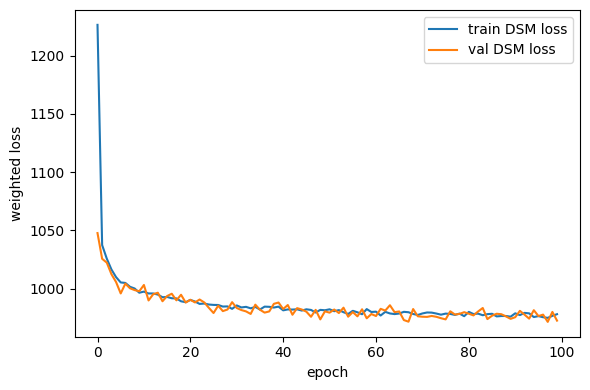

In [10]:
fig = plt.figure(figsize=(6, 4))
plt.plot(score_history["train_loss"], label="train DSM loss")
plt.plot(score_history["val_loss"], label="val DSM loss")
plt.xlabel("epoch")
plt.ylabel("weighted loss")
plt.legend()
plt.tight_layout()

## One-step denoising diagnostic

We now check both the exact target sign convention and the learned one-step denoiser. The oracle test should be numerically exact. The learned one-step plots are shown at progressively easier noise levels so that local denoising quality is easier to assess.

oracle one-step consistency check


,tau,max_abs_error,rmse
0,7.000000e-06,1.192093e-07,1.357517e-08
1,1.750000e-06,5.960464e-08,1.035432e-08
2,4.375000e-07,5.960464e-08,7.718880e-09
3,1.093750e-07,5.960464e-08,6.115515e-09


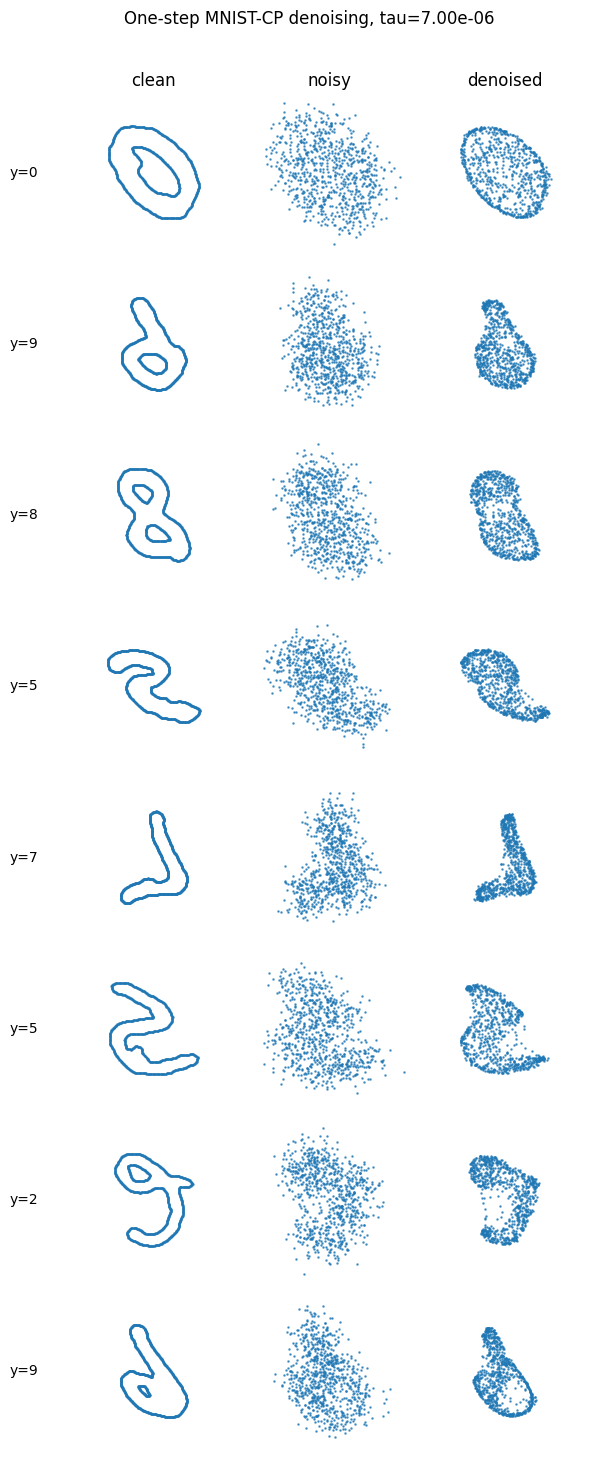

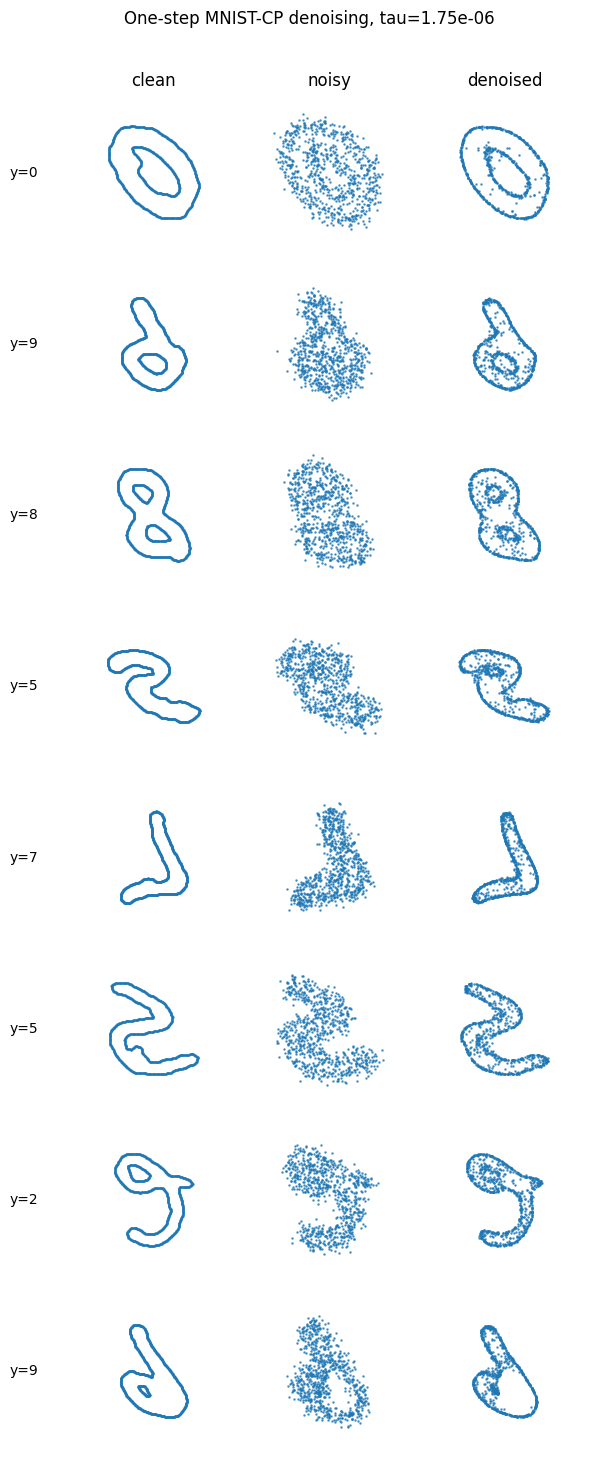

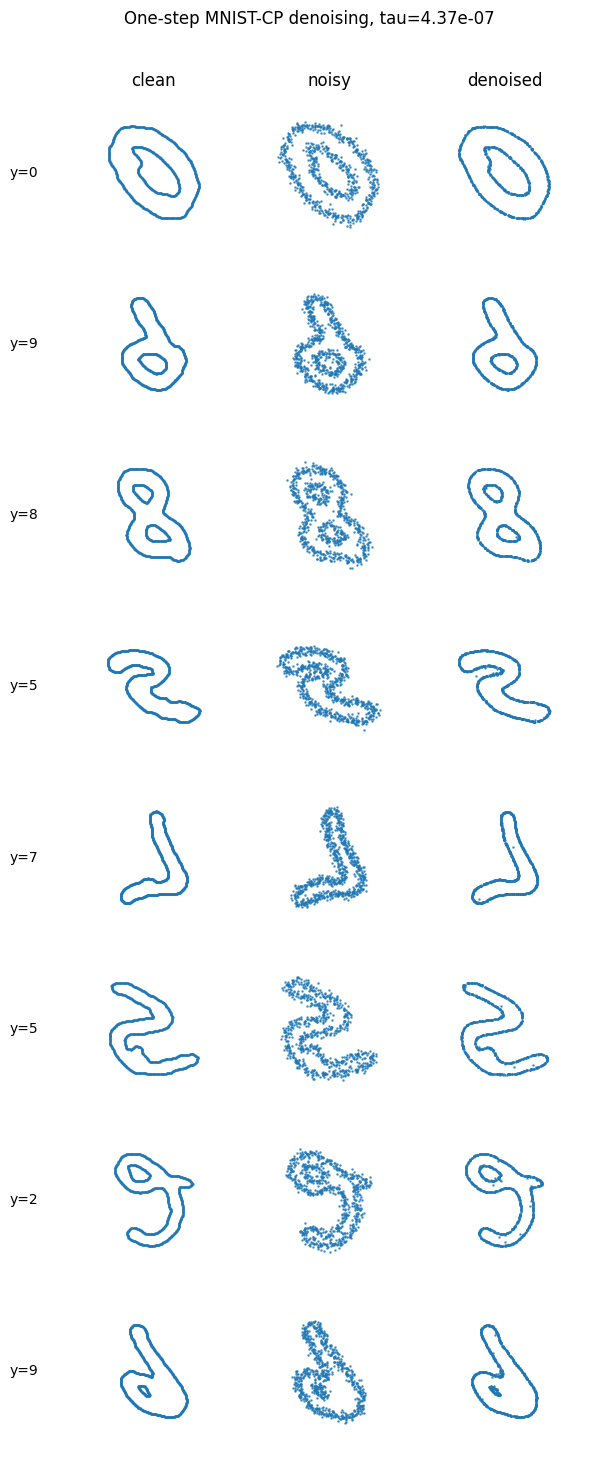

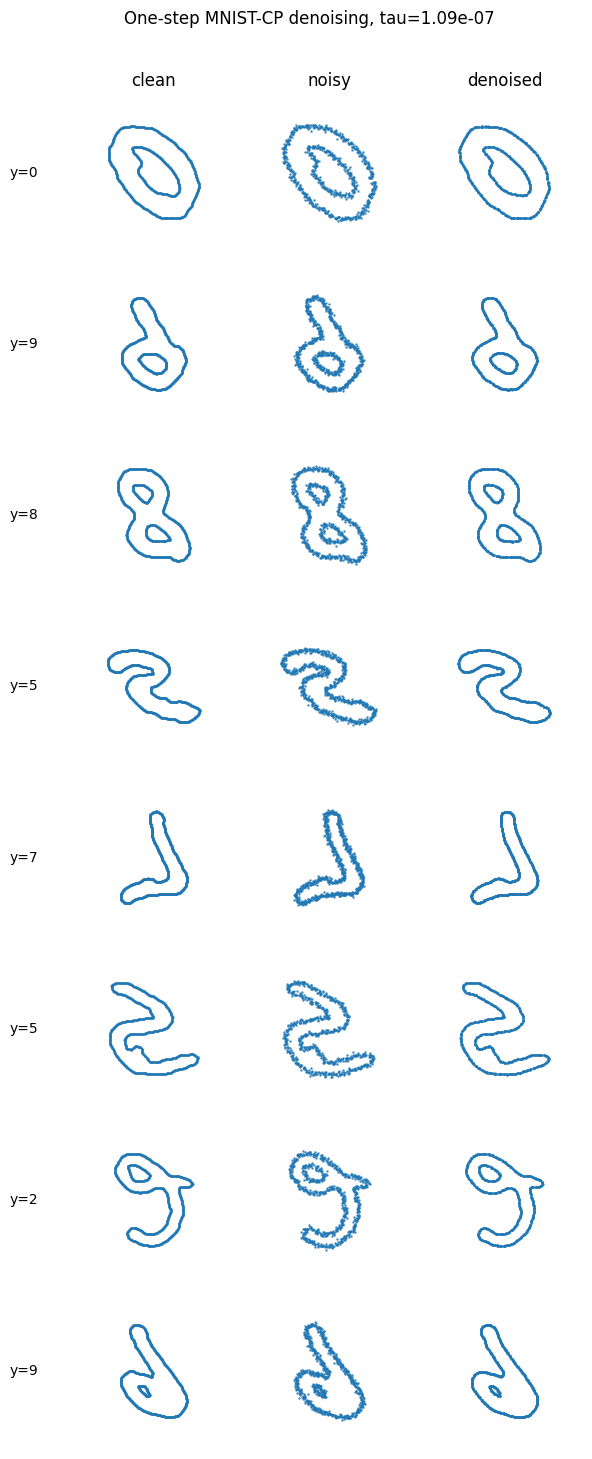

In [11]:
@torch.no_grad()
def one_step_denoising_samples(
    model,
    masses_np: np.ndarray,
    positions_np: np.ndarray,
    labels_np: np.ndarray,
    *,
    tau_value: float,
    count: int = 64,
    device: str = DEVICE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    idx = np.arange(min(count, len(labels_np)))
    masses = torch.tensor(masses_np[idx], dtype=torch.float32, device=device)
    clean = torch.tensor(positions_np[idx], dtype=torch.float32, device=device)
    labels = torch.tensor(labels_np[idx], dtype=torch.long, device=device)
    tau = torch.full((len(idx),), float(tau_value), dtype=torch.float32, device=device)

    noisy, target_score, _ = perturb_weighted_point_cloud_positions(
        masses,
        clean,
        tau,
        projection=SCORE_PROJECTION,
        score_target=SCORE_TARGET,
    )
    pred_score = model(masses, noisy, tau, labels)
    denoised = noisy + 2.0 * tau[:, None, None] * pred_score
    if SCORE_PROJECTION != "none":
        denoised = project_positions(denoised, mode=SCORE_PROJECTION)

    return (
        clean.detach().cpu().numpy(),
        noisy.detach().cpu().numpy(),
        denoised.detach().cpu().numpy(),
        labels.detach().cpu().numpy(),
    )


@torch.no_grad()
def oracle_one_step_check(
    masses_np: np.ndarray,
    positions_np: np.ndarray,
    *,
    tau_values: list[float],
    count: int = 64,
    device: str = DEVICE,
) -> pd.DataFrame:
    idx = np.arange(min(count, len(positions_np)))
    masses = torch.tensor(masses_np[idx], dtype=torch.float32, device=device)
    clean = torch.tensor(positions_np[idx], dtype=torch.float32, device=device)

    rows = []
    for tau_value in tau_values:
        tau_value = float(max(TAU_MIN, tau_value))
        tau = torch.full((len(idx),), tau_value, dtype=torch.float32, device=device)
        noisy, target_score, _ = perturb_weighted_point_cloud_positions(
            masses,
            clean,
            tau,
            projection=SCORE_PROJECTION,
            score_target=SCORE_TARGET,
        )
        oracle_denoised = noisy + 2.0 * tau[:, None, None] * target_score
        if SCORE_PROJECTION != "none":
            oracle_denoised = project_positions(oracle_denoised, mode=SCORE_PROJECTION)
        diff = oracle_denoised - clean
        rows.append(
            {
                "tau": tau_value,
                "max_abs_error": float(diff.abs().max().item()),
                "rmse": float(torch.sqrt(torch.mean(diff.pow(2))).item()),
            }
        )
    return pd.DataFrame(rows)


def plot_one_step_contours(
    clean: np.ndarray,
    noisy: np.ndarray,
    denoised: np.ndarray,
    labels: np.ndarray,
    *,
    examples: int = 8,
    title: str | None = None,
) -> None:
    n = min(examples, len(labels))
    fig, axes = plt.subplots(n, 3, figsize=(6.0, 1.8 * n), squeeze=False)
    for row in range(n):
        for col, (name, arr) in enumerate([("clean", clean), ("noisy", noisy), ("denoised", denoised)]):
            ax = axes[row, col]
            pts = arr[row]
            ax.scatter(pts[:, 0], pts[:, 1], s=0.7 if pts.shape[0] > 300 else 1.4, alpha=0.7)
            ax.set_aspect("equal")
            ax.set_xlim(-0.35, 1.35)
            ax.set_ylim(1.35, -0.35)
            ax.axis("off")
            if row == 0:
                ax.set_title(name)
            if col == 0:
                ax.text(-0.42, 0.5, f"y={int(labels[row])}", transform=ax.transAxes, va="center")
    if title is not None:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()


diagnostic_taus = sorted({
    float(max(TAU_MIN, TAU_MAX)),
    float(max(TAU_MIN, TAU_MAX / 4.0)),
    float(max(TAU_MIN, TAU_MAX / 16.0)),
    float(max(TAU_MIN, TAU_MAX / 64.0)),
}, reverse=True)

print("oracle one-step consistency check")
display(
    oracle_one_step_check(
        val_pc.masses,
        val_pc.positions,
        tau_values=diagnostic_taus,
        count=32,
    )
)

for tau_value in diagnostic_taus:
    clean, noisy, denoised, labels_used = one_step_denoising_samples(
        score_model,
        val_pc.masses,
        val_pc.positions,
        val_pc.labels,
        tau_value=tau_value,
        count=32,
    )
    plot_one_step_contours(
        clean,
        noisy,
        denoised,
        labels_used,
        examples=8,
        title=f"One-step MNIST-CP denoising, tau={tau_value:.2e}",
    )


## Generate MNIST-CP contours

The primary sampler starts from empirical contours noised at the same horizon used for score matching.  This corresponds to initializing from the empirical forward marginal at time `T`, which is the cleanest finite-horizon score-matching test.

In [12]:
primary_synthetic = generate_balanced_score_matching_dataset(
    score_model,
    train_pc.masses,
    bank_labels=train_pc.labels,
    num_points=K,
    num_per_class=SYNTHETIC_PER_CLASS,
    mass_sampling_mode="bank",
    class_conditional_mass_sampling=True,
    horizon=HORIZON,
    step_size=STEP_SIZE,
    initial_position_mode=PRIMARY_INITIAL_POSITION_MODE,
    initial_position_bank=train_pc.positions,
    initial_position_bank_labels=train_pc.labels,
    state_projection=SCORE_PROJECTION,
    diffusion_temperature=DIFFUSION_TEMPERATURE,
    score_scale=SCORE_SCALE,
    sampler_scheme=SAMPLER_SCHEME,
    batch_size=SCORE_BATCH_SIZE,
    rasterize=True,
    image_size=28,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 100),
)
print(primary_synthetic.positions.shape, primary_synthetic.labels.shape)
print("position range:", float(np.min(primary_synthetic.positions)), float(np.max(primary_synthetic.positions)))

(1280, 800, 2) (1280,)
position range: -0.00465364009141922 1.0043718814849854


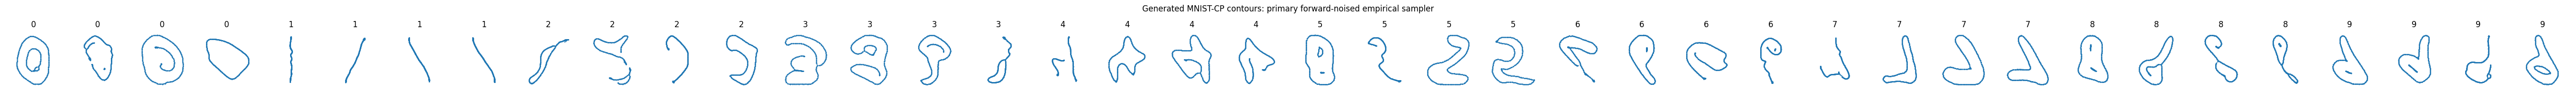

In [13]:
plot_mnist_cp_gallery(
    primary_synthetic.positions,
    primary_synthetic.labels,
    images=None,
    examples_per_label=4,
    title="Generated MNIST-CP contours: primary forward-noised empirical sampler",
    seed=SEED + 5,
    point_size=1.0 if K <= 300 else 0.35,
)

## Classifier diagnostics on generated contours

This is analogous to the auxiliary classifier metric in Experiment 7.  It is not a training signal for the score model.

,aux_accuracy,mean_target_probability,median_target_probability
label,,,
0,0.875000,0.731675,0.832367
1,0.984375,0.976659,0.999942
2,0.625000,0.569674,0.605489
3,0.664062,0.500337,0.574846
4,0.750000,0.648756,0.760539
5,0.468750,0.451354,0.367390
6,0.906250,0.861617,0.976658
7,0.703125,0.651593,0.816919
8,0.523438,0.375652,0.371265


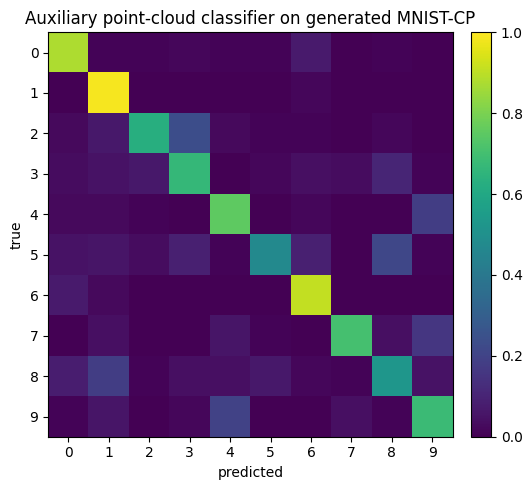

In [14]:
def generated_classifier_diagnostics(
    model: TerminalSetClassifier,
    generated: GeneratedPointCloudSet,
    *,
    batch_size: int = 128,
    device: str = DEVICE,
) -> pd.DataFrame:
    logits = predict_terminal_logits(
        model,
        generated.masses,
        generated.positions,
        batch_size=batch_size,
        device=device,
    )
    probs = softmax_np(logits)
    pred = np.argmax(logits, axis=1)
    target_prob = probs[np.arange(len(generated.labels)), generated.labels]
    return pd.DataFrame(
        {
            "label": generated.labels,
            "prediction": pred,
            "correct": pred == generated.labels,
            "target_probability": target_prob,
        }
    )


generated_diag = generated_classifier_diagnostics(eval_classifier, primary_synthetic, device=DEVICE)
summary_by_label = generated_diag.groupby("label").agg(
    aux_accuracy=("correct", "mean"),
    mean_target_probability=("target_probability", "mean"),
    median_target_probability=("target_probability", "median"),
)
confusion = confusion_matrix_from_predictions(
    primary_synthetic.labels,
    generated_diag["prediction"].to_numpy(),
    num_classes=10,
    normalize="true",
)
plot_confusion_matrix(confusion, title="Auxiliary point-cloud classifier on generated MNIST-CP")
summary_by_label

## Contour-native evaluation

For MNIST-CP, Chamfer statistics are a more direct point-cloud metric than raster CAS.  The macro metrics below are computed per class and averaged:

- `one_nn_chamfer_accuracy_macro`: 1-NN real-vs-generated two-sample accuracy; closer to 0.5 is better.
- `coverage_chamfer_macro`: fraction of real reference samples hit as nearest neighbours by generated samples; higher is better.
- `mean_real_to_generated_chamfer_macro` and `mean_generated_to_real_chamfer_macro`: lower is better.
- `mean_generated_diversity_chamfer_macro`: nearest-neighbour diversity within generated samples; too low can indicate collapse.

In [15]:
metrics = evaluate_mnist_cp_generation_metrics(
    eval_classifier,
    primary_synthetic,
    test_pc,
    chamfer_subsample_per_class=CHAMFER_SUBSAMPLE_PER_CLASS,
    squared_chamfer=True,
    device=DEVICE,
    rng=np.random.default_rng(SEED + 101),
)
summary = {
    key: value
    for key, value in metrics.items()
    if key not in {"per_label", "classifier_details"}
}
summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]
summary_df

,value
aux_point_cloud_classifier_accuracy,0.717969
aux_point_cloud_mean_target_probability,0.636451
one_nn_chamfer_accuracy_macro,0.697917
coverage_chamfer_macro,0.5
mean_real_to_generated_chamfer_macro,0.003152
mean_generated_to_real_chamfer_macro,0.003593
mean_generated_diversity_chamfer_macro,0.003017
squared_chamfer,True
chamfer_subsample_per_class,24.0


In [16]:
per_label_df = pd.DataFrame(metrics["per_label"]).T.sort_index()
per_label_df.index.name = "label"
per_label_df

,one_nn_chamfer_accuracy,coverage_chamfer,mean_real_to_generated_chamfer,mean_generated_to_real_chamfer,mean_generated_diversity_chamfer
label,,,,,
0,0.916667,0.500000,0.002379,0.003687,0.002247
1,0.791667,0.375000,0.001448,0.002299,0.000838
2,0.604167,0.583333,0.003790,0.004387,0.003837
3,0.625000,0.583333,0.002876,0.003492,0.003367
4,0.625000,0.500000,0.004155,0.003974,0.004327
5,0.750000,0.458333,0.003922,0.004124,0.003130
6,0.541667,0.541667,0.003096,0.003287,0.003228
7,0.708333,0.500000,0.003309,0.003348,0.003134
8,0.708333,0.500000,0.003863,0.004588,0.003336


## Optional: uniform-prior ablation

For MNIST-CP, the natural endpoint prior induced by the forward process is the noised empirical contour bank rather than a uniform distribution on the unit square. The uniform-prior ablation is therefore disabled by default and should be interpreted only as a stress test.

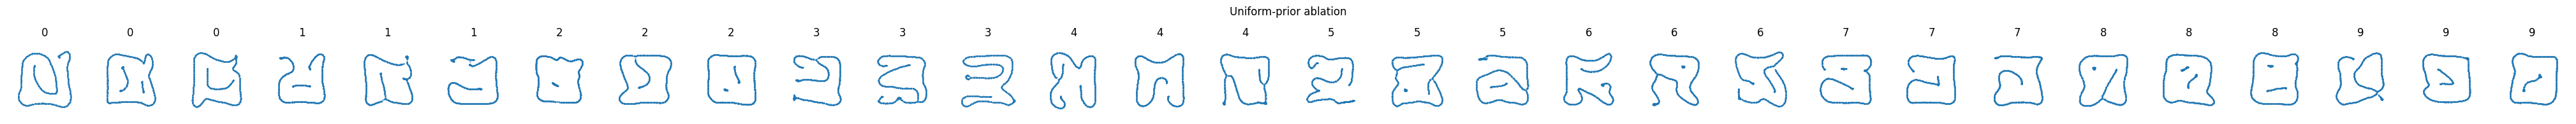

In [19]:
if RUN_UNIFORM_PRIOR_ABLATION:
    uniform_synthetic = generate_balanced_score_matching_dataset(
        score_model,
        train_pc.masses,
        bank_labels=train_pc.labels,
        num_points=K,
        num_per_class=max(8, SYNTHETIC_PER_CLASS // 2),
        mass_sampling_mode="bank",
        class_conditional_mass_sampling=True,
        horizon=HORIZON,
        step_size=STEP_SIZE,
        initial_position_mode=UNIFORM_INITIAL_POSITION_MODE,
        state_projection=SCORE_PROJECTION,
        diffusion_temperature=DIFFUSION_TEMPERATURE,
        score_scale=SCORE_SCALE,
        sampler_scheme=SAMPLER_SCHEME,
        batch_size=SCORE_BATCH_SIZE,
        rasterize=True,
        image_size=28,
        device=DEVICE,
        rng=np.random.default_rng(SEED + 200),
    )
    plot_mnist_cp_gallery(
        uniform_synthetic.positions,
        uniform_synthetic.labels,
        images=None,
        examples_per_label=3,
        title="Uniform-prior ablation",
        seed=SEED + 9,
        point_size=1.0 if K <= 300 else 0.35,
    )
else:
    uniform_synthetic = None

## Reading the results

Good signs for Experiment 8 are:

1. The one-step denoising panels recover plausible contours from noisy contours.
2. The primary generated gallery has recognizable outlines for each requested label.
3. Auxiliary point-cloud classifier accuracy is high on generated contours.
4. Chamfer 1-NN accuracy is not too far above 0.5 and coverage is not near zero.

For a full run, set `FAST_DEMO = False` and preferably `POINTS_PER_CLOUD = None` to use all 800 saved MNIST-CP contour points.  If the primary sampler looks good but the uniform-prior ablation does not, increase `HORIZON` only after checking the diagnostic that the noised endpoint is actually close to the chosen prior.